<a href="https://colab.research.google.com/github/neerajagopinath/HTML-CSS-JS/blob/main/CreditCardFraud_SHAP_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/neerajagopinath/SHAP_LIME.git

In [ ]:
!pip install shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import lime
import lime.lime_tabular

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

warnings.filterwarnings('ignore')

np.random.seed(42)
shap.initjs()

In [ ]:
df = pd.read_csv('/content/creditcard.csv')

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (124861, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df['Class'].value_counts())

print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)


Missing Values:
27

Class Distribution:
Class
0.0    124601
1.0       259
Name: count, dtype: int64

Fraud Percentage:
Class
0.0    99.792568
1.0     0.207432
Name: proportion, dtype: float64


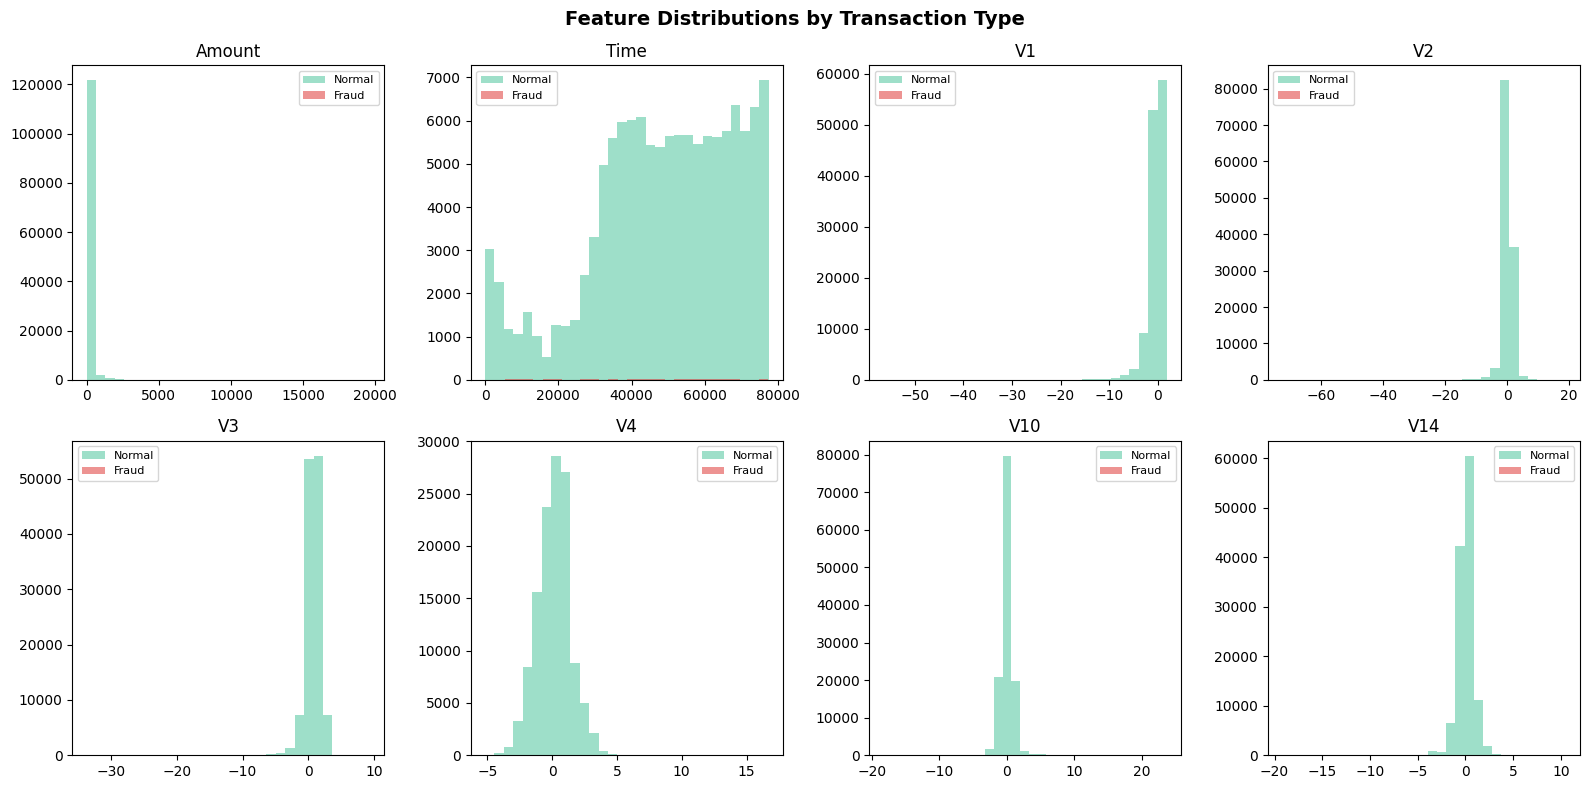

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16,8))

fig.suptitle(
    'Feature Distributions by Transaction Type',
    fontsize=14,
    fontweight='bold'
)

features_to_plot = [
    'Amount',
    'Time',
    'V1',
    'V2',
    'V3',
    'V4',
    'V10',
    'V14'
]

for ax, feat in zip(axes.flatten(), features_to_plot):

    for cls, color, label in [
        (0, '#5DCAA5', 'Normal'),
        (1, '#E24B4A', 'Fraud')
    ]:

        subset = df[df['Class']==cls][feat]

        ax.hist(
            subset,
            bins=30,
            alpha=0.6,
            color=color,
            label=label
        )

    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
df = df.dropna()

X = df.drop('Class', axis=1)
y = df['Class']

feature_names = X.columns.tolist()

print("Features:", len(feature_names))
print("Target:", y.name)

Features: 30
Target: Class


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 99888
Testing Samples : 24972


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9996


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal','Fraud']
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     24920
       Fraud       0.96      0.83      0.89        52

    accuracy                           1.00     24972
   macro avg       0.98      0.91      0.94     24972
weighted avg       1.00      1.00      1.00     24972



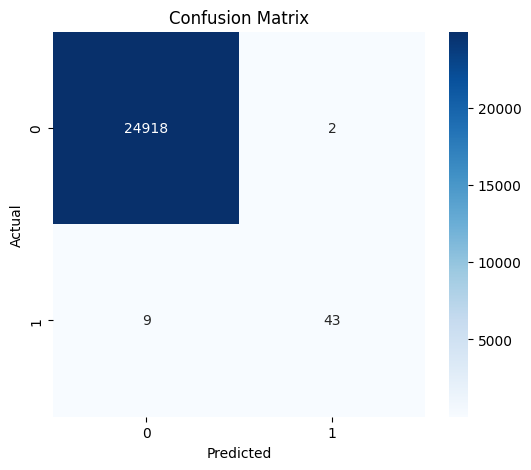

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9406767039140634


In [ ]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    fraud_shap = shap_values[1]
else:
    fraud_shap = shap_values[:,:,1]

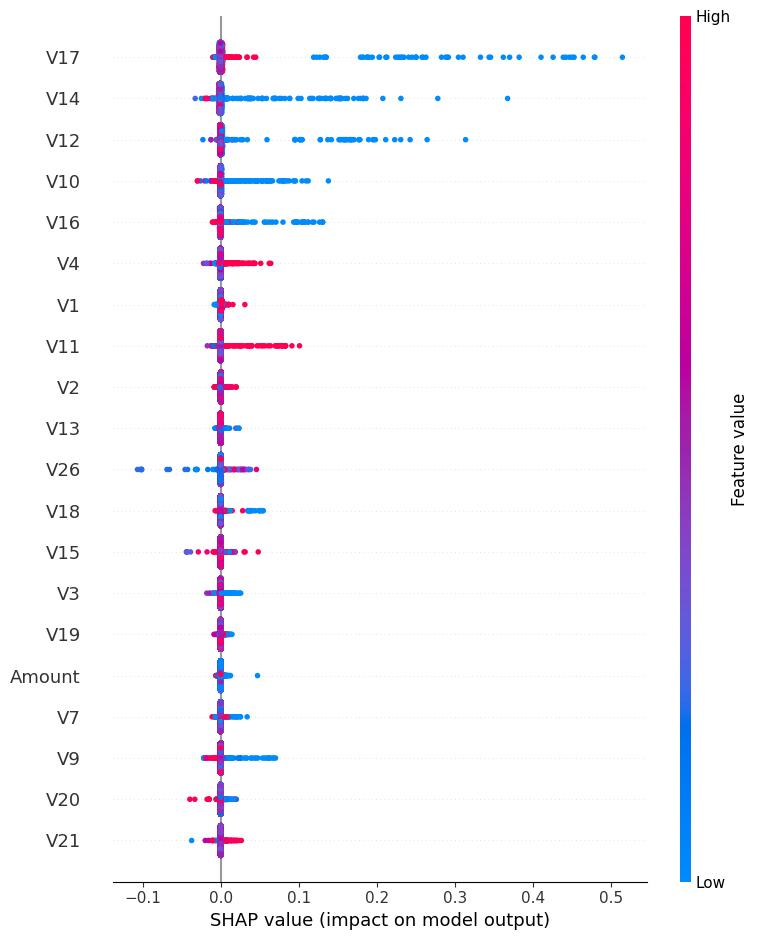

In [ ]:
shap.summary_plot(
    fraud_shap,
    X_test,
    feature_names=feature_names
)

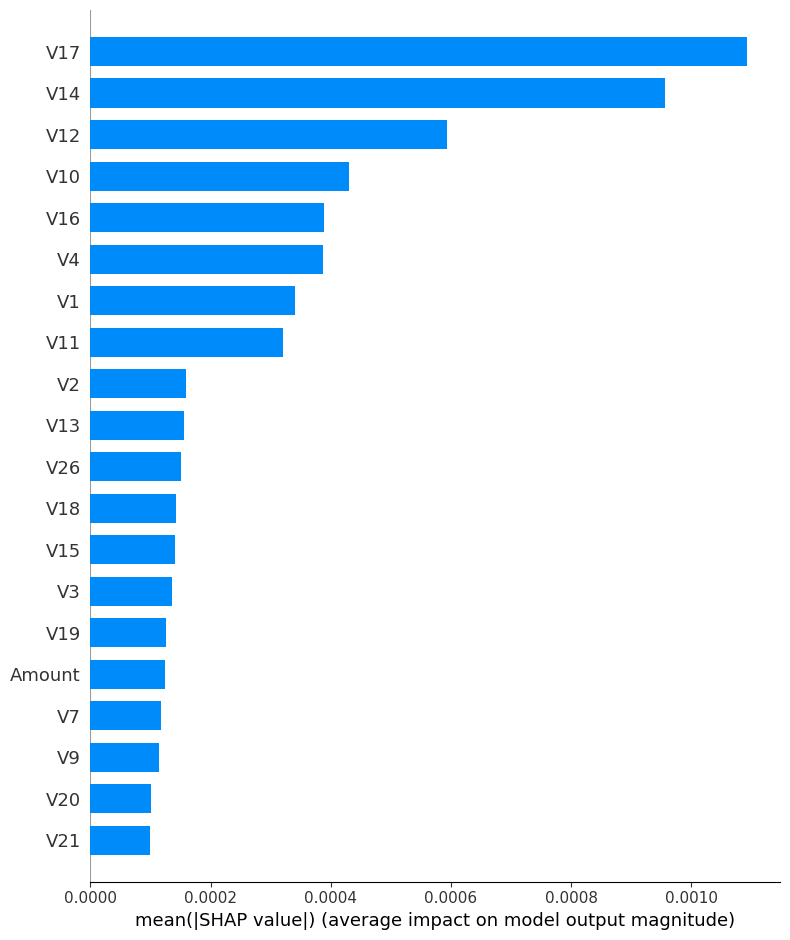

In [ ]:
shap.summary_plot(
    fraud_shap,
    X_test,
    feature_names=feature_names,
    plot_type='bar'
)

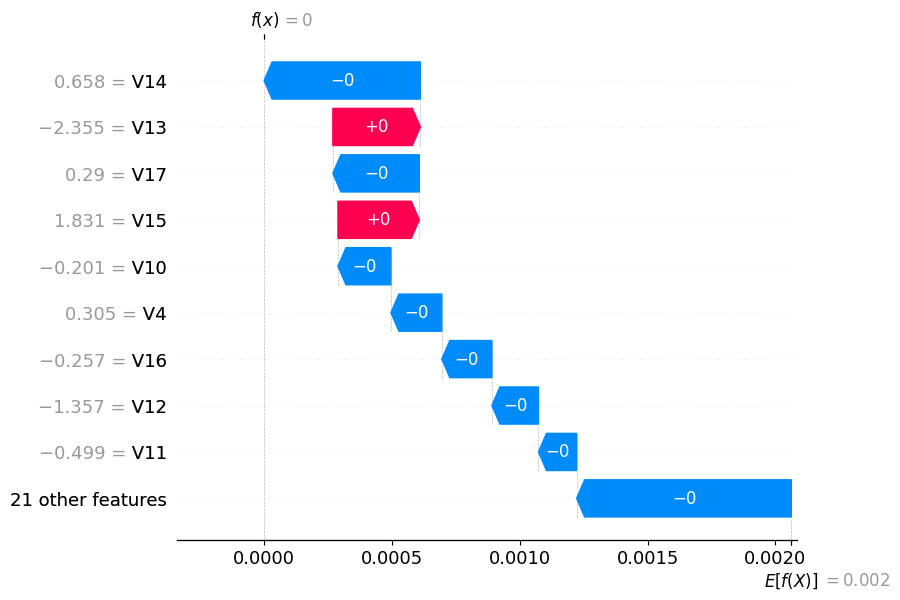

In [ ]:
transaction_idx = 0

shap_exp = shap.Explanation(
    values=fraud_shap[transaction_idx],
    base_values=explainer.expected_value[1],
    data=X_test[transaction_idx],
    feature_names=feature_names
)

shap.plots.waterfall(shap_exp)

In [ ]:
shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value[1],
    fraud_shap[transaction_idx],
    X_test[transaction_idx],
    feature_names=feature_names
)

force_plot

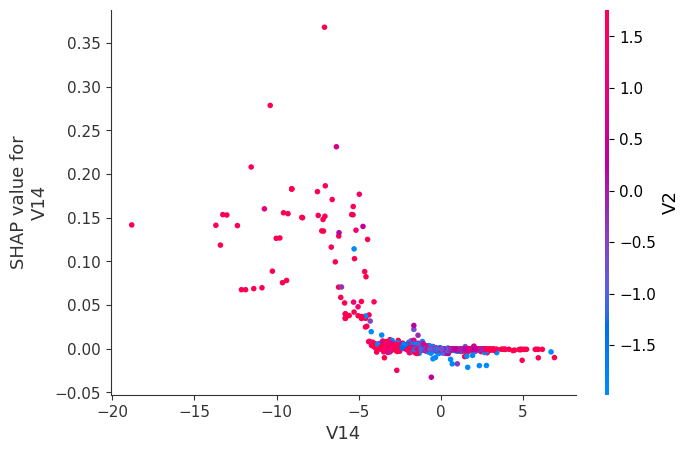

In [ ]:
shap.dependence_plot(
    "V14",
    fraud_shap,
    X_test,
    feature_names=feature_names
)

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['Normal','Fraud'],
    mode='classification'
)

In [ ]:
transaction_idx = 0

lime_exp = lime_explainer.explain_instance(
    X_test[transaction_idx],
    model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

In [ ]:
print("Top SHAP Features")

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(
        fraud_shap[transaction_idx]
    )
})

print(
    shap_importance
    .sort_values(
        'Importance',
        ascending=False
    )
    .head(10)
)

print("\nTop LIME Features")

for feat, weight in lime_exp.as_list():
    print(feat, ":", round(weight,4))

Top SHAP Features
   Feature  Importance
14     V14    0.000611
13     V13    0.000342
17     V17    0.000338
15     V15    0.000318
10     V10    0.000207
4       V4    0.000199
16     V16    0.000196
12     V12    0.000182
11     V11    0.000149
1       V1    0.000128

Top LIME Features
V20 <= -0.17 : 0.0033
-0.01 < V17 <= 0.44 : -0.0032
-1.02 < V1 <= -0.26 : -0.0028
V13 <= -0.68 : 0.0025
0.02 < V28 <= 0.08 : 0.0016
-0.48 < V10 <= -0.09 : -0.0016
0.18 < V4 <= 1.01 : -0.0015
-0.23 < V21 <= -0.06 : -0.0014
-0.32 < V24 <= 0.07 : -0.0014
V15 > 0.88 : 0.0012
